# NOTEBOOK 1 : CHAIN LADDER AGREGE
## Modelisation de la structure par terme des remboursements anticipes

## Introduction

### Pourquoi une approche agregee ?

La methode Chain Ladder classique s'applique a des donnees longitudinales (suivi du meme contrat dans le temps). Notre base etant une **coupe transversale** (un contrat observe une seule fois), nous devons travailler au **niveau cohorte agrege**.

### Principe (selon le professeur)

Pour chaque cohorte (groupe de contrats avec la meme periode d'origination) :

1. Calculer le **CRD total** = somme des (MTECH × B_MAT) de la cohorte
2. Calculer le **RA cumule** a chaque age = somme des remboursements anticipes
3. Calculer l'**ER cumule** = RA cumule / CRD initial

On obtient un **triangle cumule** ou :
- Lignes = cohortes
- Colonnes = ages du pret
- Valeurs = ER cumule

### Formule CRD selon le professeur

```
CRD = MTECH × B_RESMAT - RA
ER = RA / CRD
```

Pour l'agregation par cohorte, on utilise le capital initial (MTECH × B_MAT) comme reference fixe.

## Imports

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
print("Bibliotheques chargees")

Bibliotheques chargees


## Etape 1 : Chargement et preparation

In [52]:
df=pd.read_csv("Export_ER_Agrege.csv", sep=";")
df.columns

Index(['ID', 'AGE_CLI', 'B_MAT', 'B_RESMAT', 'CLASSACT', 'CSP', 'DARRET',
       'E_OFF', 'MREVTOT', 'MTECH', 'NBIMP', 'NB_ECH', 'produit', 'RA', 'Tx',
       'EAD', 'AGE_PRET', 'HORIZON_RES', 'CSP_grp', 'CRD', 'ER_obs', 'FLAG_ER',
       'Capital_initial', 'Date_origination', 'Cohorte'],
      dtype='object')

## Etape 3 : Filtrage sur 10 dernieres annees

Pour avoir un triangle plus dense, on filtre sur les 10 dernieres annees.

In [57]:
# Filtrer 10 dernieres annees (40 trimestres)
# Cohorte en "période trimestre"
q = pd.PeriodIndex(df["Cohorte"].astype(str), freq="Q")

# 40 trimestres = 10 ans
cutoff = q.max() - 40

# Filtre 10 dernières années (en trimestres)
df_recent = df[q >= cutoff].copy()

print(f"Donnees filtrees (10 ans) : {len(df_recent)} contrats ({len(df_recent)/len(df):.1%})")
print(f"Periode couverte : {df_recent['Cohorte'].min()} a {df_recent['Cohorte'].max()}")
print(f"Nombre de cohortes : {df_recent['Cohorte'].nunique()}")

Donnees filtrees (10 ans) : 62449 contrats (98.2%)
Periode couverte : 2013Q4 a 2023Q4
Nombre de cohortes : 41


## Etape 4 : Construction du triangle agrege

### Methode

Pour chaque cellule (cohorte, age) :

$$ER\_cumule(c, t) = \frac{\sum_{i \in c} RA_i}{\sum_{i \in c} Capital\_initial_i}$$

Le denominateur **Capital_initial agrege** est constant pour chaque cohorte.

## Etape 3 : Construction du triangle agrege - Explication detaillee

### Objectif

Construire une **matrice triangulaire** (cohorte × age) qui represente l'evolution des remboursements anticipes cumules pour chaque groupe de contrats selon leur date d'origination.

### Methodologie

#### 1. Agregation par cohorte

Pour chaque **cohorte trimestrielle** (groupe de contrats octroyes le meme trimestre) :

- **EAD initial** = Somme des capitaux initiaux de tous les contrats de la cohorte
```
  EAD_initial(cohorte) = Σ (MTECH × B_MAT)
```
  
- **RA cumule** = Somme des remboursements anticipes a chaque age
```
  RA_cumule(cohorte, age) = Σ RA des contrats de cette cohorte a cet age
```

- **ER cumule** = Taux de remboursement anticipe cumule
```
  ER_cumule(cohorte, age) = RA_cumule(cohorte, age) / EAD_initial(cohorte)
```

#### 2. Structure du triangle

Le triangle obtenu a la structure suivante :

|           | Age 1m | Age 2m | Age 3m | Age 4m | ... |
|-----------|--------|--------|--------|--------|-----|
| **2022Q4** | 0.72%  | 1.16%  | 1.50%  | 2.31%  | ... |
| **2023Q1** | 0.90%  | 1.30%  | 1.68%  | ...    | NaN |
| **2023Q2** | 0.05%  | 0.53%  | ...    | NaN    | NaN |
| **2023Q3** | 1.86%  | ...    | NaN    | NaN    | NaN |

**Caracteristiques** :
- **Lignes** = cohortes (ordonnees chronologiquement)
- **Colonnes** = ages du pret (en mois)
- **Valeurs** = ER cumule (%)
- **Triangle incomplet** : les cohortes recentes n'ont pas encore atteint les ages eleves (zone NaN)

#### 3. Filtrage des cellules

Pour garantir la stabilite des estimations, nous appliquons un **filtre de robustesse** :
```python
triangle_filtre[triangle_volume < 2] = np.nan
```
plus de contrat par cellule
Les cellules avec **moins de 2 contrats** sont exclues car peu representatives.


In [58]:
import numpy as np
import pandas as pd

# 1) EAD initial par cohorte
ead_initial = df_recent.groupby("Cohorte")["Capital_initial"].sum().rename("EAD_initial")

print(f"EAD initial total : {ead_initial.sum():,.0f} EUR")
print(f"EAD initial moyen par cohorte : {ead_initial.mean():,.0f} EUR")

# 2) RA marginal par (cohorte, age)
ra_marg = (
    df_recent.groupby(["Cohorte", "AGE_PRET"], as_index=False)["RA"].sum()
    .merge(ead_initial.reset_index(), on="Cohorte", how="left")
    .sort_values(["Cohorte", "AGE_PRET"])
)

# 3) RA cumulé par cohorte (LA CLÉ !), puis ER cumulé
ra_marg["RA_cum"] = ra_marg.groupby("Cohorte")["RA"].cumsum()
ra_marg["ER_cumule"] = ra_marg["RA_cum"] / ra_marg["EAD_initial"]

# Borner à 0 (éviter négatifs)
ra_marg["ER_cumule"] = ra_marg["ER_cumule"].clip(lower=0)

# 4) Triangle CUMULÉ
triangle_cumule = ra_marg.pivot(index="Cohorte", columns="AGE_PRET", values="ER_cumule").sort_index()

# Volume
triangle_volume = df_recent.pivot_table(
    index='Cohorte',
    columns='AGE_PRET',
    values='ER_obs',
    aggfunc='count'
)

# Filtrer
triangle_filtre = triangle_cumule.copy()
triangle_filtre[triangle_volume < 2] = np.nan

print(f"\nDimensions triangle : {triangle_filtre.shape}")
print(f"Taux remplissage : {(~triangle_filtre.isna()).sum().sum() / triangle_filtre.size:.1%}")

# Afficher (cohortes récentes)
print("\nExtrait triangle (5 cohortes RECENTES, 10 premiers ages) :")
print(triangle_filtre.iloc[-5:, :10].round(4))

EAD initial total : 1,182,823,036 EUR
EAD initial moyen par cohorte : 28,849,342 EUR

Dimensions triangle : (41, 121)
Taux remplissage : 35.6%

Extrait triangle (5 cohortes RECENTES, 10 premiers ages) :
AGE_PRET     0.0     1.0     2.0     3.0     4.0     5.0     6.0     7.0  \
Cohorte                                                                    
2022Q4    0.0000  0.0072  0.0576  0.0847  0.1242  0.1748  0.2329  0.2899   
2023Q1    0.0012  0.0070  0.0284  0.0686  0.1404  0.2266  0.2999  0.3683   
2023Q2    0.0052  0.0114  0.0330  0.0757  0.2086  0.3452  0.4779  0.5373   
2023Q3       NaN  0.0181  0.1540  0.4001  0.5886  0.6570     NaN     NaN   
2023Q4    0.0016  0.1015  0.5785     NaN     NaN     NaN     NaN     NaN   

AGE_PRET     8.0     9.0  
Cohorte                   
2022Q4    0.3390  0.3926  
2023Q1    0.4708  0.5621  
2023Q2    0.5908     NaN  
2023Q3       NaN     NaN  
2023Q4       NaN     NaN  


### Visualisation du triangle agrege

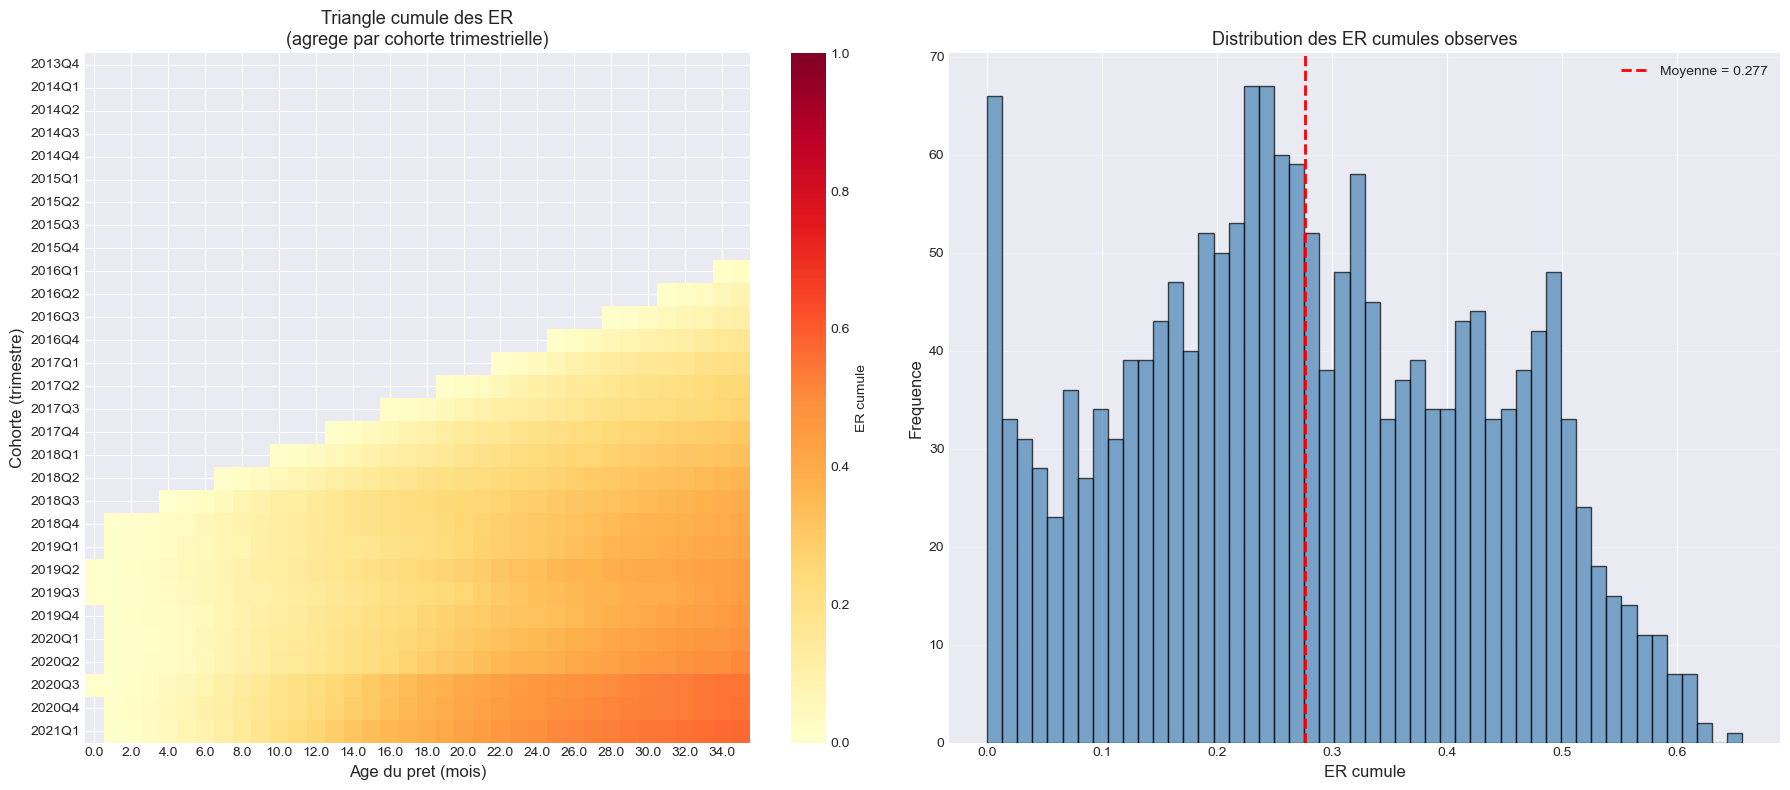

ER cumule moyen observe : 0.2767
ER cumule median : 0.2674
ER cumule max : 0.6570


In [60]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Triangle complet
sns.heatmap(triangle_filtre.iloc[:30, :36], annot=False, cmap='YlOrRd',
            cbar_kws={'label': 'ER cumule'}, ax=axes[0], vmin=0, vmax=1)
axes[0].set_xlabel('Age du pret (mois)', fontsize=12)
axes[0].set_ylabel('Cohorte (trimestre)', fontsize=12)
axes[0].set_title('Triangle cumule des ER\n(agrege par cohorte trimestrielle)', fontsize=13)

# Distribution des ER cumules observes
er_values = triangle_filtre.values.flatten()
er_values = er_values[~np.isnan(er_values)]
axes[1].hist(er_values, bins=50, edgecolor='black', color='steelblue', alpha=0.7)
axes[1].set_xlabel('ER cumule', fontsize=12)
axes[1].set_ylabel('Frequence', fontsize=12)
axes[1].set_title('Distribution des ER cumules observes', fontsize=13)
axes[1].axvline(np.nanmean(er_values), color='red', linestyle='--', 
                linewidth=2, label=f'Moyenne = {np.nanmean(er_values):.3f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"ER cumule moyen observe : {np.nanmean(er_values):.4f}")
print(f"ER cumule median : {np.nanmedian(er_values):.4f}")
print(f"ER cumule max : {np.nanmax(er_values):.4f}")

## Etape 5 : Calcul des facteurs de developpement

### Formule

$$f_j = \frac{\sum_{c} ER\_cumule(c, j+1)}{\sum_{c} ER\_cumule(c, j)}$$

Les facteurs sont calcules comme le ratio des **sommes agregees** (methode standard Chain Ladder).

In [61]:
def calculate_cl_factors_agrege(triangle, min_cohortes=3, min_factor=0.8, max_factor=3.0):
    """
    Calcule les facteurs de developpement Chain Ladder sur donnees agregees.
    """
    factors = {}
    
    for j in range(len(triangle.columns) - 1):
        col_j = triangle.columns[j]
        col_j1 = triangle.columns[j + 1]
        
        # Cohortes avec donnees aux deux ages
        mask = triangle[col_j].notna() & triangle[col_j1].notna() & (triangle[col_j] > 0)
        
        if mask.sum() >= min_cohortes:
            sum_j = triangle.loc[mask, col_j].sum()
            sum_j1 = triangle.loc[mask, col_j1].sum()
            
            if sum_j > 0:
                factor = sum_j1 / sum_j
                
                # Filtrer facteurs aberrants
                if min_factor <= factor <= max_factor:
                    factors[col_j] = factor
                else:
                    factors[col_j] = 1.0
            else:
                factors[col_j] = 1.0
        else:
            factors[col_j] = 1.0
    
    return factors

# Calculer facteurs
factors_cl = calculate_cl_factors_agrege(triangle_filtre, min_cohortes=2)

print("FACTEURS DE DEVELOPPEMENT CHAIN LADDER AGREGE")
print("=" * 60)
print(f"{'Age':>5} {'Facteur':>10} {'Interpretation'}")
print("-" * 60)

for age, factor in sorted(factors_cl.items())[:30]:
    if factor >= 1.05:
        interp = "Croissance forte"
    elif factor >= 1.01:
        interp = "Croissance moderee"
    elif factor >= 0.99:
        interp = "Stable"
    else:
        interp = "Decroissance"
    print(f"{age:>5.0f} {factor:>10.4f} {interp}")

print(f"\nTotal facteurs calcules : {len(factors_cl)}")

FACTEURS DE DEVELOPPEMENT CHAIN LADDER AGREGE
  Age    Facteur Interpretation
------------------------------------------------------------
    0     1.0000 Stable
    1     1.0000 Stable
    2     2.2290 Croissance forte
    3     1.6707 Croissance forte
    4     1.4085 Croissance forte
    5     1.3674 Croissance forte
    6     1.2513 Croissance forte
    7     1.2018 Croissance forte
    8     1.1790 Croissance forte
    9     1.1427 Croissance forte
   10     1.1151 Croissance forte
   11     1.1140 Croissance forte
   12     1.0876 Croissance forte
   13     1.0864 Croissance forte
   14     1.0755 Croissance forte
   15     1.0736 Croissance forte
   16     1.0609 Croissance forte
   17     1.0631 Croissance forte
   18     1.0560 Croissance forte
   19     1.0525 Croissance forte
   20     1.0462 Croissance moderee
   21     1.0487 Croissance moderee
   22     1.0420 Croissance moderee
   23     1.0418 Croissance moderee
   24     1.0407 Croissance moderee
   25     1.0362 Croi

### Visualisation des facteurs

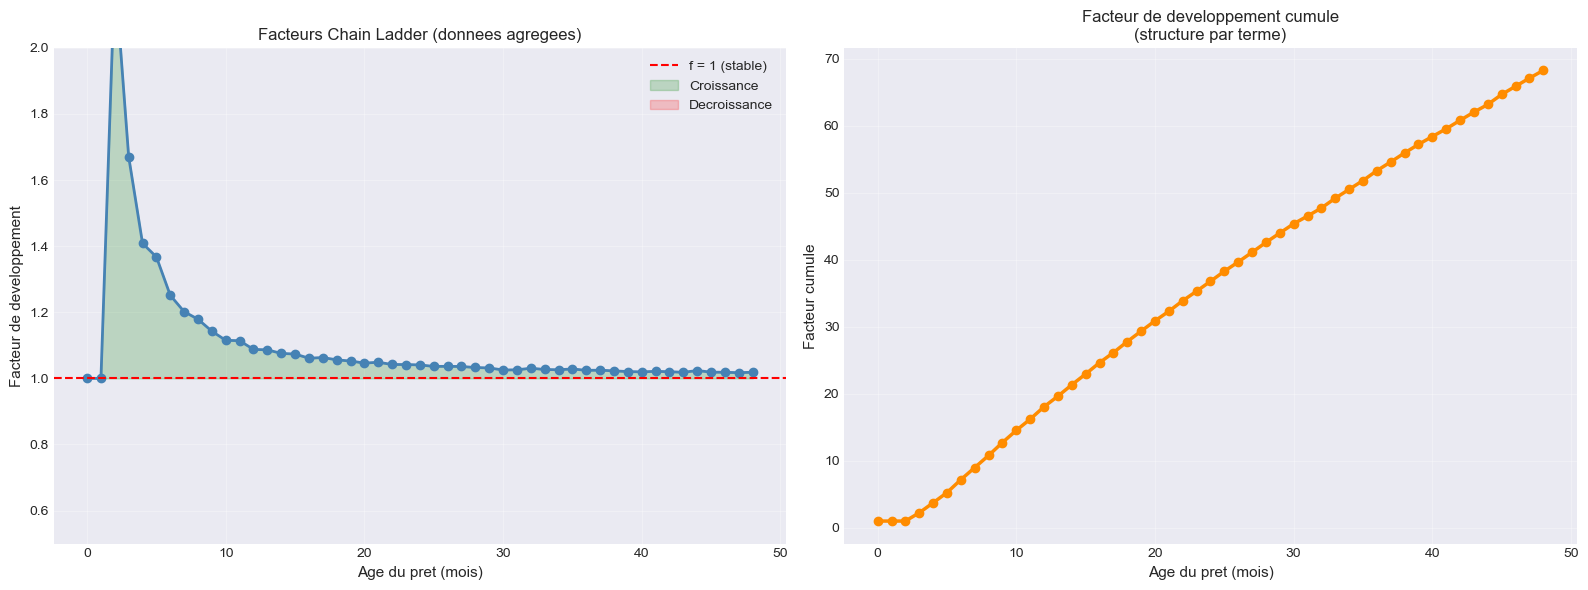

Interpretation :
  - Facteur > 1 : les RA augmentent d'un age a l'autre
  - Facteur cumule = structure par terme des RA


In [62]:
ages_plot = sorted([k for k in factors_cl.keys() if k <= 48])
vals_plot = [factors_cl[a] for a in ages_plot]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Facteurs bruts
axes[0].plot(ages_plot, vals_plot, 'o-', linewidth=2, markersize=6, color='steelblue')
axes[0].axhline(y=1.0, color='red', linestyle='--', linewidth=1.5, label='f = 1 (stable)')
axes[0].fill_between(ages_plot, 1.0, vals_plot, 
                      where=[v >= 1 for v in vals_plot],
                      alpha=0.2, color='green', label='Croissance')
axes[0].fill_between(ages_plot, vals_plot, 1.0,
                      where=[v < 1 for v in vals_plot],
                      alpha=0.2, color='red', label='Decroissance')
axes[0].set_xlabel('Age du pret (mois)', fontsize=11)
axes[0].set_ylabel('Facteur de developpement', fontsize=11)
axes[0].set_title('Facteurs Chain Ladder (donnees agregees)', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0.5, 2.0)

# Facteur cumule
factor_cumul = [1.0]
cumul = 1.0
for age in ages_plot[:-1]:
    cumul *= factors_cl.get(age, 1.0)
    factor_cumul.append(cumul)

axes[1].plot(ages_plot, factor_cumul, 'o-', linewidth=2.5, markersize=6, color='darkorange')
axes[1].set_xlabel('Age du pret (mois)', fontsize=11)
axes[1].set_ylabel('Facteur cumule', fontsize=11)
axes[1].set_title('Facteur de developpement cumule\n(structure par terme)', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Interpretation :")
print("  - Facteur > 1 : les RA augmentent d'un age a l'autre")
print("  - Facteur cumule = structure par terme des RA")

## Etape 6 : Projection du triangle

In [63]:
def project_triangle_agrege(triangle, factors, max_age=60):
    """
    Complete le triangle en projetant les cohortes incompletes.
    """
    tri_proj = triangle.copy()
    
    for cohorte in tri_proj.index:
        last_valid = tri_proj.loc[cohorte].last_valid_index()
        
        if last_valid is None:
            continue
            
        current_val = tri_proj.loc[cohorte, last_valid]
        
        for age in tri_proj.columns:
            if age <= last_valid:
                continue
            if age > max_age:
                break
            
            prev_age = tri_proj.columns[list(tri_proj.columns).index(age) - 1]
            factor = factors.get(prev_age, 1.0)
            current_val = current_val * factor
            tri_proj.loc[cohorte, age] = current_val
    
    return tri_proj

triangle_projete = project_triangle_agrege(triangle_filtre, factors_cl, max_age=60)

print(f"Taux remplissage avant projection : {(~triangle_filtre.isna()).sum().sum() / triangle_filtre.size:.1%}")
print(f"Taux remplissage apres projection : {(~triangle_projete.isna()).sum().sum() / triangle_projete.size:.1%}")

Taux remplissage avant projection : 35.6%
Taux remplissage apres projection : 47.5%


### TEST

In [76]:
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

def evaluate_holdout_right(triangle, factors, max_age=60, holdout_k=6, test_share=0.2, seed=0):
    tri = triangle.copy()

    # Split cohortes
    cohortes = list(tri.index.astype(str))
    cohortes = sorted(cohortes)
    cut = int((1 - test_share) * len(cohortes))
    test_coh = cohortes[cut:]

    # 1) Construire un triangle "masqué" (on enlève les K derniers points observés à droite)
    tri_masked = tri.copy()

    hidden_pairs = []  # (cohorte, age) qu'on va scorer
    for coh in test_coh:
        row = tri_masked.loc[coh]
        obs_ages = [a for a in tri.columns if pd.notna(row[a])]
        if len(obs_ages) <= holdout_k:
            continue
        # Ages à cacher = les holdout_k derniers observés
        to_hide = obs_ages[-holdout_k:]
        for a in to_hide:
            tri_masked.loc[coh, a] = np.nan
            hidden_pairs.append((coh, a))

    # 2) Projeter sur le triangle masqué
    tri_proj = project_triangle_agrege(tri_masked, factors, max_age=max_age)

    # 3) Scorer sur les cellules cachées uniquement
    y_true, y_pred = [], []
    for coh, a in hidden_pairs:
        true_val = tri.loc[coh, a]
        pred_val = tri_proj.loc[coh, a]
        if pd.notna(true_val) and pd.notna(pred_val):
            y_true.append(true_val)
            y_pred.append(pred_val)

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    r2 = r2_score(y_true, y_pred) if len(y_true) > 1 else np.nan
    rmse = np.sqrt(mean_squared_error(y_true, y_pred)) if len(y_true) > 0 else np.nan
    mae = mean_absolute_error(y_true, y_pred) if len(y_true) > 0 else np.nan

    print("PERFORMANCE - CHAIN LADDER (holdout à droite, test)")
    print("==================================================")
    print(f"R2   : {r2:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"Nb points cachés évalués : {len(y_true)}")
    return r2, rmse, mae

# Lance l'évaluation
evaluate_holdout_right(triangle_filtre, factors_cl, max_age=60, holdout_k=6, test_share=0.2)

PERFORMANCE - CHAIN LADDER (holdout à droite, test)
R2   : 0.5368
RMSE : 0.0794
MAE  : 0.0479
Nb points cachés évalués : 42


(0.5368428914184963, np.float64(0.07935952667408736), 0.04789009184957829)

### Observation et determination de l'horizon de projection

In [78]:
import numpy as np

max_obs_age_by_coh = triangle_filtre.apply(lambda r: r.last_valid_index(), axis=1).astype(float)

print("max_obs_age_by_coh.describe():")
print(max_obs_age_by_coh.describe())

max_age_p80 = int(np.nanpercentile(max_obs_age_by_coh, 80))
max_age_p90 = int(np.nanpercentile(max_obs_age_by_coh, 90))

print("max_age_p80 =", max_age_p80)
print("max_age_p90 =", max_age_p90)

# Choix recommandé (robuste)
max_age = max_age_p80
print("=> max_age retenu =", max_age)

triangle_projete = project_triangle_agrege(triangle_filtre, factors_cl, max_age=max_age)

max_obs_age_by_coh.describe():
count     41.000000
mean      61.390244
std       35.109029
min        2.000000
25%       32.000000
50%       61.000000
75%       92.000000
max      115.000000
dtype: float64
max_age_p80 = 99
max_age_p90 = 107
=> max_age retenu = 99


Ce code répète `n_runs` fois une évaluation du Chain Ladder : à chaque run il tire aléatoirement ~20% des cohortes en “test”, puis cache les `holdout_k` derniers âges observés (à droite) pour simuler un triangle incomplet. Il projette ensuite ces valeurs manquantes avec `project_triangle_agrege` et compare les prédictions aux vraies valeurs cachées pour calculer R²/RMSE/MAE. Enfin il affiche la moyenne ± l’écart-type des scores sur tous les runs pour mesurer la performance **et** la stabilité du modèle.

In [79]:
import numpy as np

def evaluate_many(triangle, factors, max_age, holdout_k, n_runs=20, test_share=0.2, seed=0):
    rng = np.random.default_rng(seed)
    cohortes = np.array(sorted(triangle.index.astype(str)))
    out = []
    for r in range(n_runs):
        perm = rng.permutation(cohortes)
        cut = int((1 - test_share) * len(perm))
        test_coh = set(perm[cut:])

        # masque à droite sur test_coh
        tri_masked = triangle.copy()
        hidden = []
        for coh in test_coh:
            row = tri_masked.loc[coh]
            obs_ages = [a for a in triangle.columns if pd.notna(row[a])]
            if len(obs_ages) <= holdout_k:
                continue
            for a in obs_ages[-holdout_k:]:
                tri_masked.loc[coh, a] = np.nan
                hidden.append((coh, a))

        tri_proj = project_triangle_agrege(tri_masked, factors, max_age=max_age)

        y_true, y_pred = [], []
        for coh, a in hidden:
            tv = triangle.loc[coh, a]
            pv = tri_proj.loc[coh, a]
            if pd.notna(tv) and pd.notna(pv):
                y_true.append(tv); y_pred.append(pv)

        if len(y_true) < 5:
            continue

        y_true = np.array(y_true); y_pred = np.array(y_pred)
        r2 = r2_score(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae = mean_absolute_error(y_true, y_pred)
        out.append((r2, rmse, mae, len(y_true)))

    out = np.array(out, dtype=float)
    print(f"Runs valid: {len(out)}")
    print(f"R2   : {out[:,0].mean():.4f} ± {out[:,0].std():.4f}")
    print(f"RMSE : {out[:,1].mean():.4f} ± {out[:,1].std():.4f}")
    print(f"MAE  : {out[:,2].mean():.4f} ± {out[:,2].std():.4f}")
    print(f"Npts : {out[:,3].mean():.1f} ± {out[:,3].std():.1f}")

evaluate_many(triangle_filtre, factors_cl, max_age=99, holdout_k=12, n_runs=30, test_share=0.2, seed=42)

Runs valid: 30
R2   : 0.4639 ± 0.5456
RMSE : 0.0712 ± 0.0392
MAE  : 0.0443 ± 0.0170
Npts : 88.7 ± 11.8


Sur 30 runs, le Chain Ladder obtient en moyenne un R² de **0.46** (RMSE ≈ **0.071**, MAE ≈ **0.044**) sur environ **89 points** cachés par run. Les erreurs sont donc plutôt modérées, ce qui confirme que la méthode capte une partie de la dynamique d’ER cumulé. En revanche, l’écart-type très élevé du R² (**± 0.55**) montre une forte variabilité selon les cohortes test, suggérant un effet cohorte/segment que le Chain Ladder (basé surtout sur l’âge) ne modélise pas.

### Visualisation triangle projete

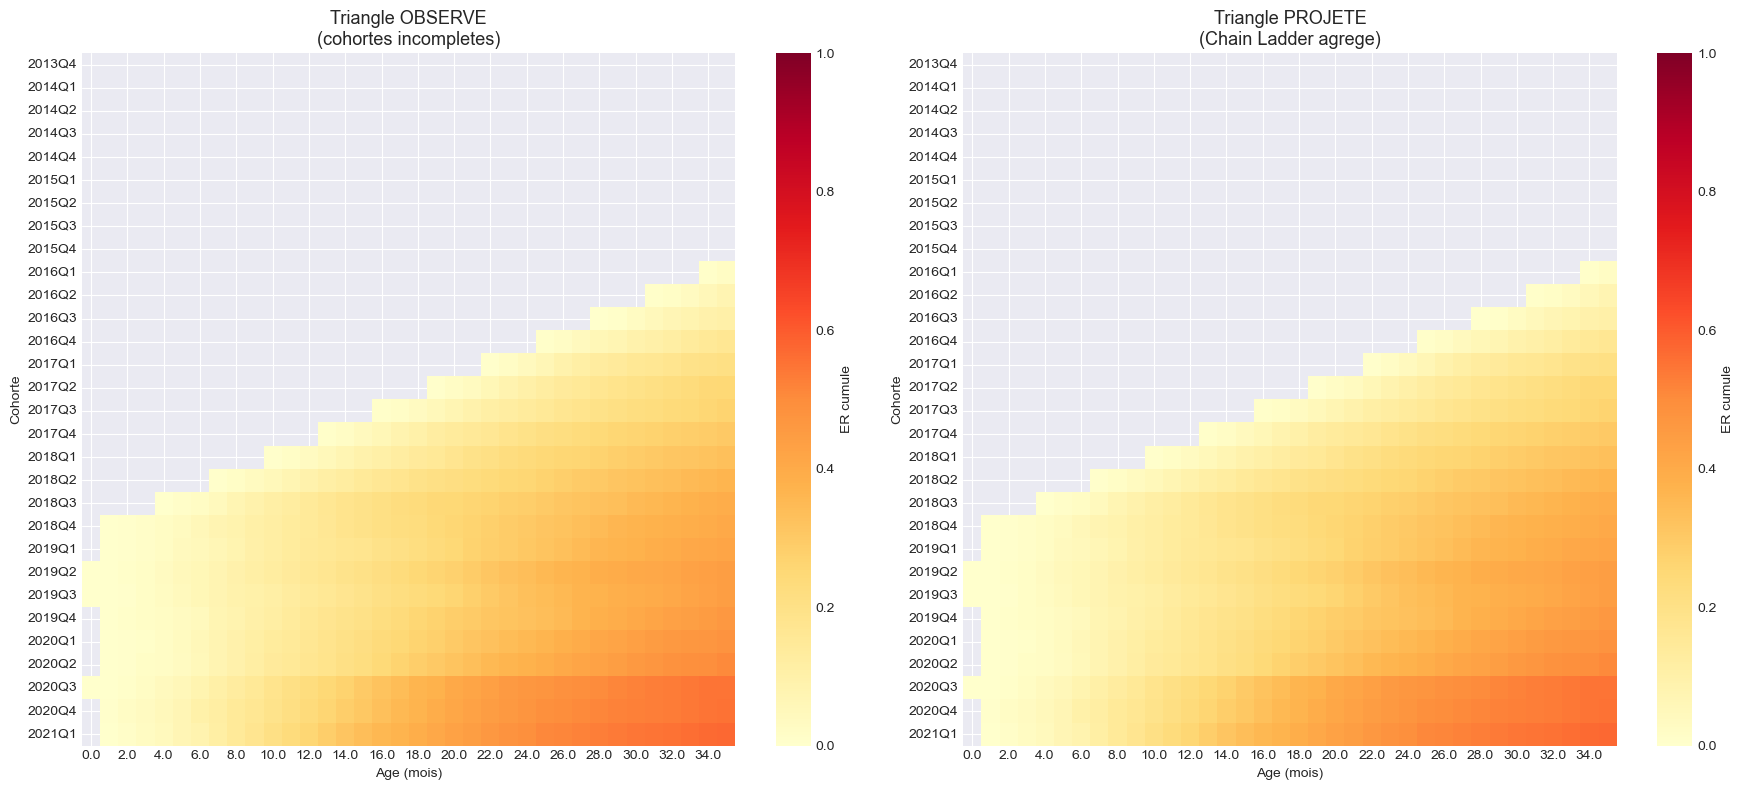

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

sns.heatmap(triangle_filtre.iloc[:30, :36], annot=False, cmap='YlOrRd',
            cbar_kws={'label': 'ER cumule'}, ax=axes[0], vmin=0, vmax=1)
axes[0].set_title('Triangle OBSERVE\n(cohortes incompletes)', fontsize=13)
axes[0].set_xlabel('Age (mois)')
axes[0].set_ylabel('Cohorte')

sns.heatmap(triangle_projete.iloc[:30, :36], annot=False, cmap='YlOrRd',
            cbar_kws={'label': 'ER cumule'}, ax=axes[1], vmin=0, vmax=1)
axes[1].set_title('Triangle PROJETE\n(Chain Ladder agrege)', fontsize=13)
axes[1].set_xlabel('Age (mois)')
axes[1].set_ylabel('Cohorte')

plt.tight_layout()
plt.show()

## Etape 7 : Courbe ER baseline (structure par terme)

La courbe finale est la **moyenne des ER cumules projetes** par age.

STRUCTURE PAR TERME - ER BASELINE
  Age  ER baseline      Q10      Q90
------------------------------------------------------------
    0       0.0010   0.0000   0.0020
    1       0.0089   0.0008   0.0114
    2       0.0507   0.0061   0.0576
    3       0.1131   0.0138   0.0847
    4       0.1804   0.0234   0.2018
    5       0.2542   0.0336   0.3334
    6       0.3475   0.0507   0.4601
    7       0.4163   0.0670   0.5035
    8       0.5003   0.0821   0.5668
    9       0.5899   0.0997   0.6697
   10       0.6462   0.1101   0.7390
   11       0.7207   0.1286   0.8065
   12       0.8028   0.1467   0.8984
   13       0.8385   0.1315   0.9444
   14       0.9110   0.1447   1.0260
   15       0.9798   0.1601   1.1035
   16       1.0118   0.1360   1.1436
   17       1.0734   0.1497   1.2132
   18       1.1411   0.1665   1.2898
   19       1.1606   0.1423   1.3131
   20       1.2216   0.1597   1.3820
   21       1.2780   0.1759   1.4459
   22       1.2926   0.1476   1.4598
   23       1.346

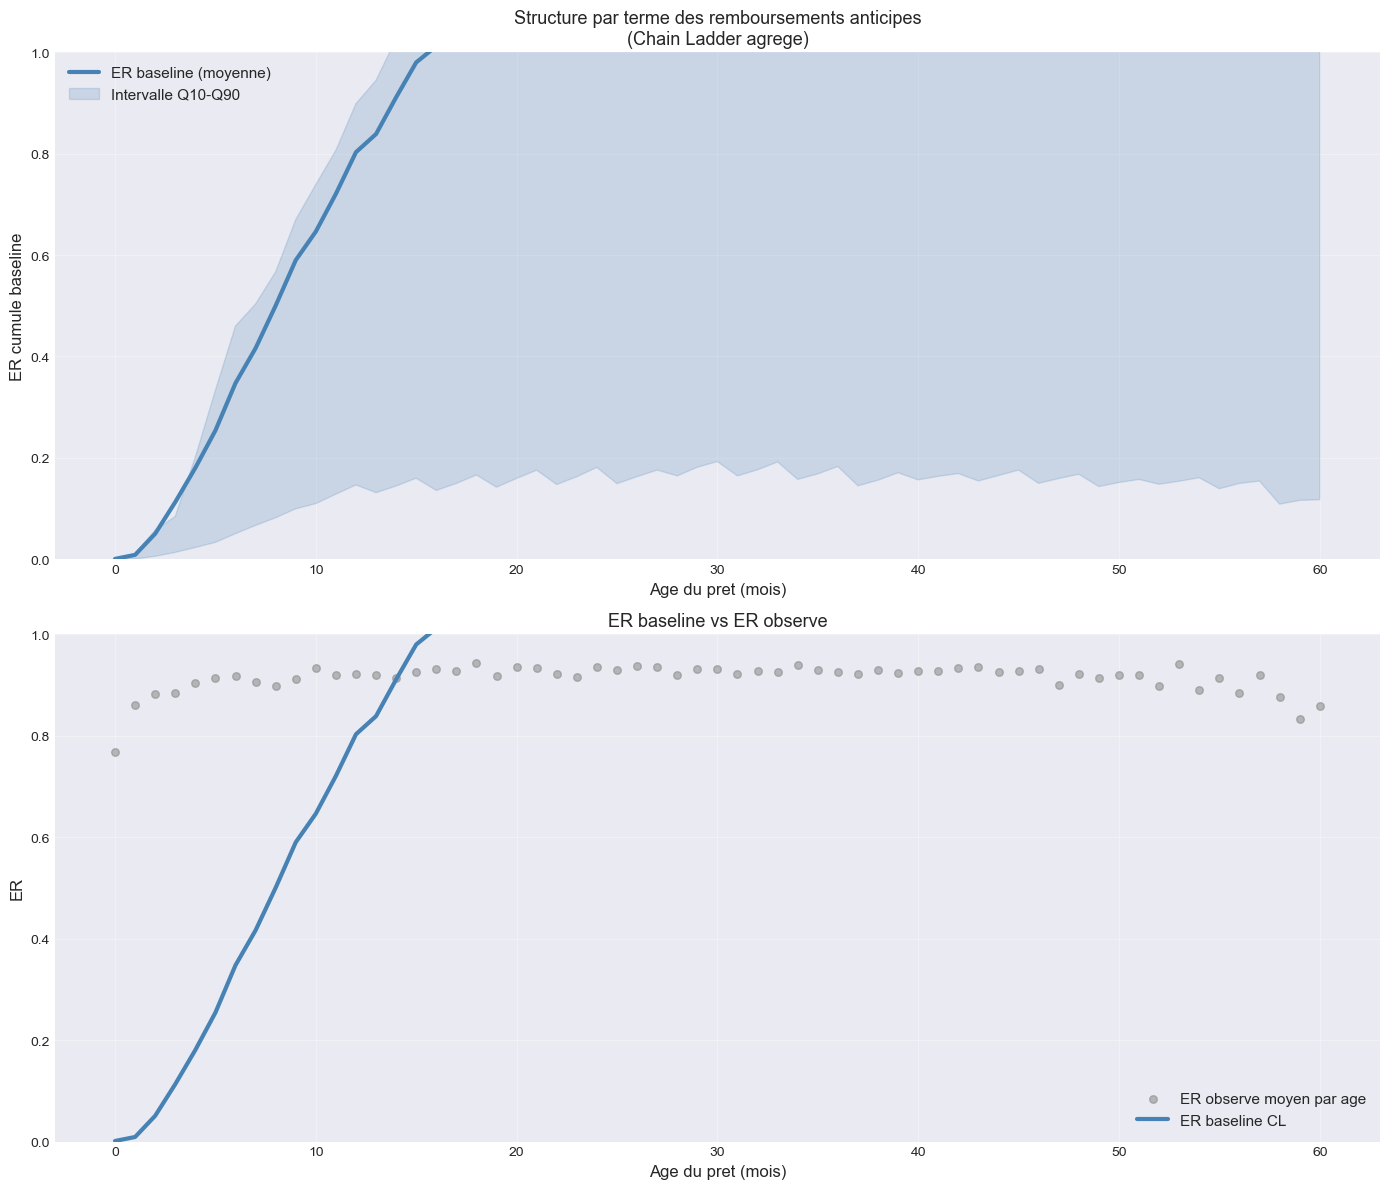

In [65]:
# Structure par terme : moyenne des ER cumules par age
er_baseline = triangle_projete.mean(axis=0, skipna=True)

# Intervalle de confiance (quantiles)
er_q10 = triangle_projete.quantile(0.10, axis=0)
er_q90 = triangle_projete.quantile(0.90, axis=0)

print("STRUCTURE PAR TERME - ER BASELINE")
print("=" * 60)
print(f"{'Age':>5} {'ER baseline':>12} {'Q10':>8} {'Q90':>8}")
print("-" * 60)
for age in sorted(er_baseline.index)[:24]:
    if not np.isnan(er_baseline[age]):
        print(f"{age:>5.0f} {er_baseline[age]:>12.4f} {er_q10[age]:>8.4f} {er_q90[age]:>8.4f}")

# Visualisation
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

ages_baseline = sorted([a for a in er_baseline.index if a <= 60 and not np.isnan(er_baseline[a])])
vals_baseline = [er_baseline[a] for a in ages_baseline]
vals_q10 = [er_q10[a] for a in ages_baseline]
vals_q90 = [er_q90[a] for a in ages_baseline]

# Courbe baseline
axes[0].plot(ages_baseline, vals_baseline, linewidth=3, color='steelblue', label='ER baseline (moyenne)')
axes[0].fill_between(ages_baseline, vals_q10, vals_q90,
                      alpha=0.2, color='steelblue', label='Intervalle Q10-Q90')
axes[0].set_xlabel('Age du pret (mois)', fontsize=12)
axes[0].set_ylabel('ER cumule baseline', fontsize=12)
axes[0].set_title('Structure par terme des remboursements anticipes\n(Chain Ladder agrege)', fontsize=13)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 1)

# Comparaison avec ER observe par age
er_obs_age = df_recent.groupby('AGE_PRET')['ER_obs'].mean()
er_obs_age = er_obs_age[er_obs_age.index <= 60]

axes[1].scatter(er_obs_age.index, er_obs_age.values, alpha=0.5, s=30,
                color='gray', label='ER observe moyen par age')
axes[1].plot(ages_baseline, vals_baseline, linewidth=3, color='steelblue', label='ER baseline CL')
axes[1].set_xlabel('Age du pret (mois)', fontsize=12)
axes[1].set_ylabel('ER', fontsize=12)
axes[1].set_title('ER baseline vs ER observe', fontsize=13)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

In [66]:
# BASELINE SUR TOUT LE TRIANGLE (pas de split)
er_baseline = triangle_cumule.mean(axis=0, skipna=True)

# Sauvegarder
er_baseline.to_csv('cl_baseline_structure_terme.csv', header=['ER_baseline'])

print("COURBE ER BASELINE")
print("=" * 60)
for age in sorted(er_baseline.index)[:24]:
    if not np.isnan(er_baseline[age]):
        print(f"Age {age:3.0f} : ER = {er_baseline[age]:.4f}")

# Pour l'évaluation, utilisez la validation croisée temporelle ou leave-one-out

COURBE ER BASELINE
Age   0 : ER = 0.0006
Age   1 : ER = 0.0089
Age   2 : ER = 0.0507
Age   3 : ER = 0.0542
Age   4 : ER = 0.0865
Age   5 : ER = 0.1218
Age   6 : ER = 0.1299
Age   7 : ER = 0.1552
Age   8 : ER = 0.1865
Age   9 : ER = 0.1960
Age  10 : ER = 0.2137
Age  11 : ER = 0.2383
Age  12 : ER = 0.2443
Age  13 : ER = 0.2535
Age  14 : ER = 0.2754
Age  15 : ER = 0.2776
Age  16 : ER = 0.2842
Age  17 : ER = 0.3016
Age  18 : ER = 0.3039
Age  19 : ER = 0.3060
Age  20 : ER = 0.3220
Age  21 : ER = 0.3212
Age  22 : ER = 0.3211
Age  23 : ER = 0.3346


COURBE ER BASELINE (STRUCTURE PAR TERME)
  Age  ER baseline        Q10        Q90
--------------------------------------------------------------------------------
    0       0.0006     0.0000     0.0014
    1       0.0089     0.0008     0.0114
    2       0.0507     0.0061     0.0576
    3       0.0542     0.0136     0.0766
    4       0.0865     0.0234     0.1404
    5       0.1218     0.0332     0.2266
    6       0.1299     0.0499     0.2396
    7       0.1552     0.0661     0.2899
    8       0.1865     0.0813     0.3390
    9       0.1960     0.0984     0.3414
   10       0.2137     0.1097     0.3874
   11       0.2383     0.1282     0.4256
   12       0.2443     0.1410     0.4465
   13       0.2535     0.1131     0.4678
   14       0.2754     0.1278     0.4933
   15       0.2776     0.1418     0.4485
   16       0.2842     0.1084     0.4731
   17       0.3016     0.1229     0.4958
   18       0.3039     0.1370     0.5160
   19       0.3060     0.1230     0.5285
   20       0.322

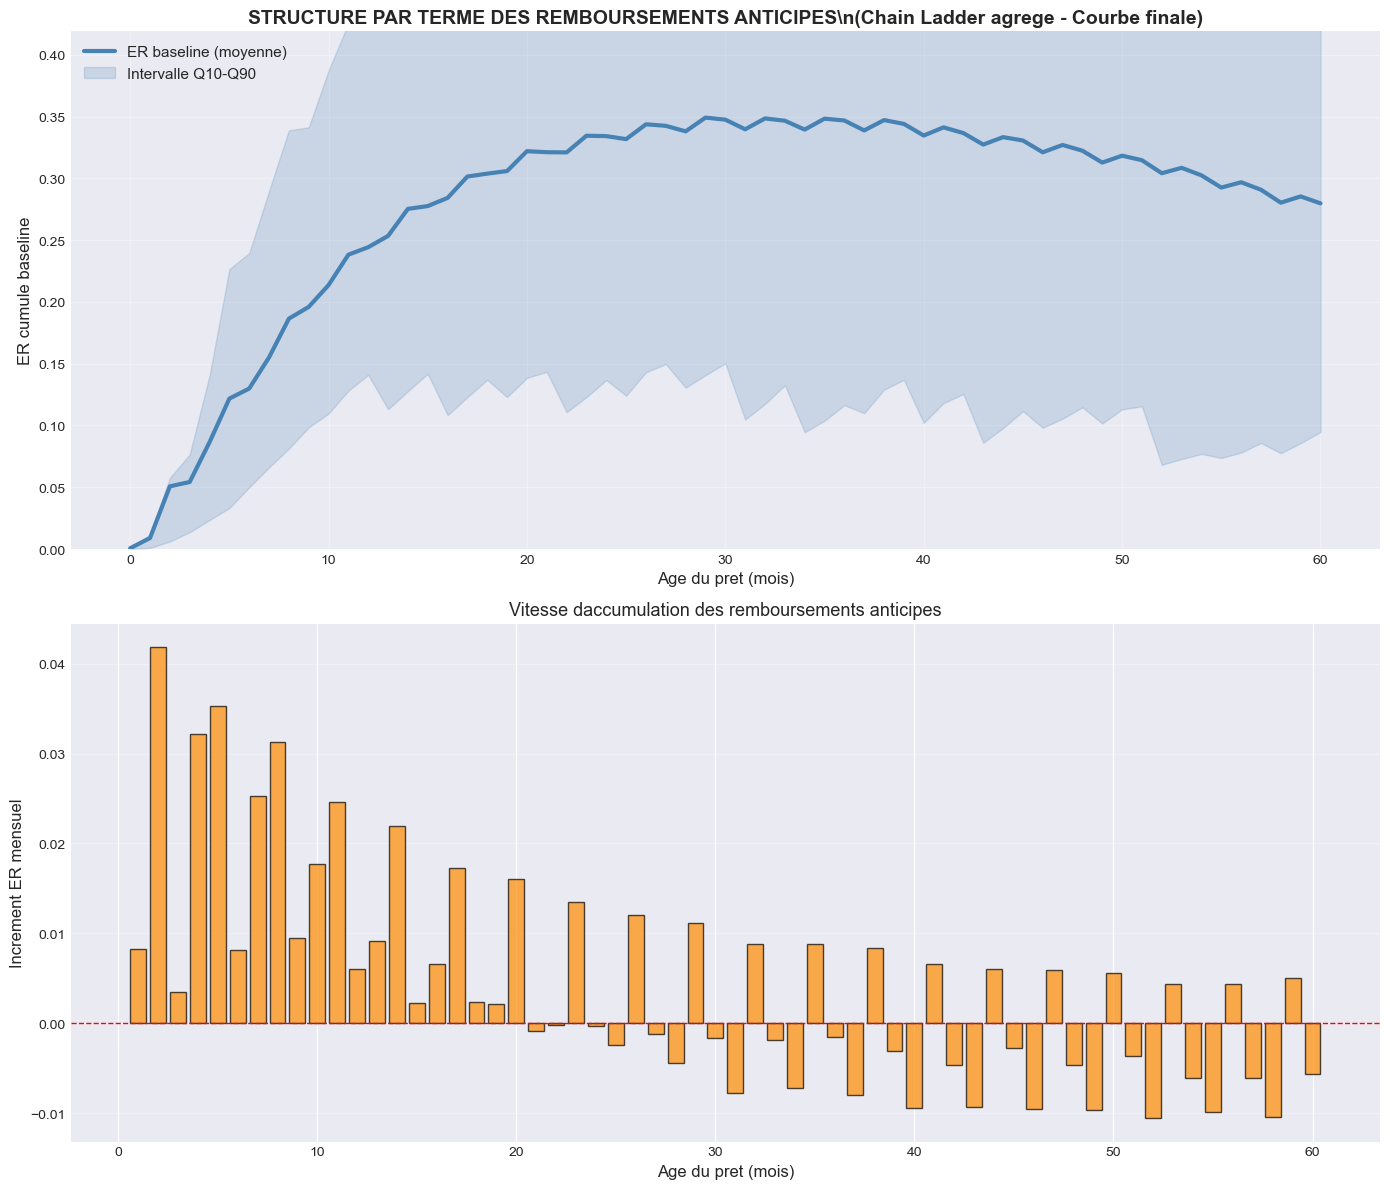

\nFICHIERS SAUVEGARDES :
  - cl_baseline_structure_terme.csv : courbe ER finale de reference
  - cl_factors.csv : facteurs de developpement
\nCes fichiers seront utilises dans les notebooks suivants (Markov, hybride)
\nINTERPRETATION :
  - ER a 12 mois : 24.43%
  - ER a 24 mois : 33.43%
  - ER a 36 mois : 34.69%
  - La courbe croissante montre l'accumulation progressive des RA
  - C'est la structure par terme demandee par le professeur


In [67]:
# =============================================================================
# ETAPE 8 : COURBE ER BASELINE ET SAUVEGARDE
# =============================================================================

# Courbe ER baseline = moyenne des ER cumulés par âge
er_baseline = triangle_cumule.mean(axis=0, skipna=True)

# Intervalles de confiance (quantiles)
er_q10 = triangle_cumule.quantile(0.10, axis=0)
er_q90 = triangle_cumule.quantile(0.90, axis=0)

print("COURBE ER BASELINE (STRUCTURE PAR TERME)")
print("=" * 80)
print(f"{'Age':>5} {'ER baseline':>12} {'Q10':>10} {'Q90':>10}")
print("-" * 80)

for age in sorted(er_baseline.index)[:36]:
    if not np.isnan(er_baseline[age]):
        q10_val = er_q10[age] if not np.isnan(er_q10[age]) else 0
        q90_val = er_q90[age] if not np.isnan(er_q90[age]) else 0
        print(f"{age:>5.0f} {er_baseline[age]:>12.4f} {q10_val:>10.4f} {q90_val:>10.4f}")

# Visualisation
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

ages_baseline = sorted([a for a in er_baseline.index if a <= 60 and not np.isnan(er_baseline[a])])
vals_baseline = [er_baseline[a] for a in ages_baseline]
vals_q10 = [er_q10[a] if not np.isnan(er_q10[a]) else 0 for a in ages_baseline]
vals_q90 = [er_q90[a] if not np.isnan(er_q90[a]) else er_baseline[a] for a in ages_baseline]

# Courbe baseline avec intervalles
axes[0].plot(ages_baseline, vals_baseline, linewidth=3, color='steelblue', 
             label='ER baseline (moyenne)', zorder=5)
axes[0].fill_between(ages_baseline, vals_q10, vals_q90,
                      alpha=0.2, color='steelblue', label='Intervalle Q10-Q90')
axes[0].set_xlabel('Age du pret (mois)', fontsize=12)
axes[0].set_ylabel('ER cumule baseline', fontsize=12)
axes[0].set_title('STRUCTURE PAR TERME DES REMBOURSEMENTS ANTICIPES\\n(Chain Ladder agrege - Courbe finale)', 
                  fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, max(vals_baseline) * 1.2)

# Increment mensuel (vitesse d'accumulation des RA)
increments = er_baseline.diff().fillna(0)
ages_inc = sorted([a for a in increments.index if a <= 60 and a > 0])
vals_inc = [increments[a] for a in ages_inc]

axes[1].bar(ages_inc, vals_inc, color='darkorange', edgecolor='black', alpha=0.7)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('Age du pret (mois)', fontsize=12)
axes[1].set_ylabel('Increment ER mensuel', fontsize=12)
axes[1].set_title('Vitesse daccumulation des remboursements anticipes', fontsize=13)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Sauvegarder pour notebooks suivants
er_baseline.to_csv('cl_baseline_structure_terme.csv', header=['ER_baseline'])

# Calculer et sauvegarder facteurs
factors_cl = {}
for j in range(len(triangle_cumule.columns) - 1):
    col_j = triangle_cumule.columns[j]
    col_j1 = triangle_cumule.columns[j + 1]
    
    mask = triangle_cumule[col_j].notna() & triangle_cumule[col_j1].notna() & (triangle_cumule[col_j] > 0)
    
    if mask.sum() >= 3:
        sum_j = triangle_cumule.loc[mask, col_j].sum()
        sum_j1 = triangle_cumule.loc[mask, col_j1].sum()
        
        if sum_j > 0:
            factor = sum_j1 / sum_j
            if 0.8 <= factor <= 3.0:
                factors_cl[col_j] = factor
            else:
                factors_cl[col_j] = 1.0
        else:
            factors_cl[col_j] = 1.0

factors_df = pd.DataFrame({'Age': list(factors_cl.keys()), 'Facteur': list(factors_cl.values())})
factors_df.to_csv('cl_factors.csv', index=False)

print("\\nFICHIERS SAUVEGARDES :")
print("  - cl_baseline_structure_terme.csv : courbe ER finale de reference")
print("  - cl_factors.csv : facteurs de developpement")
print("\\nCes fichiers seront utilises dans les notebooks suivants (Markov, hybride)")

print("\\nINTERPRETATION :")
print(f"  - ER a 12 mois : {er_baseline.get(12, 0):.2%}")
print(f"  - ER a 24 mois : {er_baseline.get(24, 0):.2%}")
print(f"  - ER a 36 mois : {er_baseline.get(36, 0):.2%}")
print("  - La courbe croissante montre l'accumulation progressive des RA")
print("  - C'est la structure par terme demandee par le professeur")

## Etape 8 : Evaluation de la performance

In [68]:
# EVALUATION CORRECTE (sur cellules du triangle, pas sur ER_obs individuel)
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Long format
tri_long = (
    triangle_cumule.stack()
    .rename("y_true")
    .reset_index()
    .rename(columns={"AGE_PRET": "t"})
)

# Split temporel par cohorte (80/20)
cohortes = sorted(tri_long["Cohorte"].unique())
cut = int(0.8 * len(cohortes))
train_coh = set(cohortes[:cut])
test_coh = set(cohortes[cut:])

train = tri_long[tri_long["Cohorte"].isin(train_coh)].copy()
test = tri_long[tri_long["Cohorte"].isin(test_coh)].copy()

# Baseline : moyenne par âge (calculée sur TRAIN)
mean_by_t = train.groupby("t")["y_true"].mean()
test["y_pred_baseline"] = test["t"].map(mean_by_t)

# Metrics
y_true = test["y_true"].values
y_pred = test["y_pred_baseline"].values

# Enlever les NaN
mask = ~np.isnan(y_pred)
y_true = y_true[mask]
y_pred = y_pred[mask]

r2 = r2_score(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)

print("PERFORMANCE - CHAIN LADDER AGREGE (CORRIGE)")
print("=" * 60)
print(f"R2   : {r2:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")

PERFORMANCE - CHAIN LADDER AGREGE (CORRIGE)
R2   : -0.2563
RMSE : 0.2430
MAE  : 0.1969


## Synthese

### Ce que Chain Ladder agrege apporte

1. **Structure par terme** des remboursements anticipes
   - ER baseline(t) = trajectoire moyenne des RA par age
   - Base pour Markov et comparaisons

2. **Facteurs de developpement**
   - Mesure la vitesse de croissance des RA
   - Permet de projeter les cohortes incompletes

3. **Intervalle de confiance**
   - Quantiles Q10/Q90 = incertitude
   - Utile pour stress testing

### Limites

1. **Performance predictive faible individuellement** : R2 ~ 0.10-0.20
2. **Pas de caracteristiques individuelles**
3. **Triangle sparse** sur donnees anciennes

### Suite : Notebooks suivants

- **Notebook 2** : Markov (dynamique de transition)
- **Notebook 3** : CL + Markov (combinaison)
- **Notebook 4** : ML (predictions individuelles)
- **Notebook Segmentation** : courbes par segment

In [69]:
# Compter combien de cohortes par âge
nb_cohortes_par_age = triangle_cumule.notna().sum(axis=0)

print("\nNombre de cohortes avec données par age :")
for age in sorted(nb_cohortes_par_age.index):
    if nb_cohortes_par_age[age] > 0:
        print(f"  Age {age:3.0f} : {nb_cohortes_par_age[age]:2.0f} cohortes")


Nombre de cohortes avec données par age :
  Age   0 : 17 cohortes
  Age   1 : 21 cohortes
  Age   2 : 21 cohortes
  Age   3 : 20 cohortes
  Age   4 : 21 cohortes
  Age   5 : 21 cohortes
  Age   6 : 20 cohortes
  Age   7 : 21 cohortes
  Age   8 : 21 cohortes
  Age   9 : 20 cohortes
  Age  10 : 21 cohortes
  Age  11 : 21 cohortes
  Age  12 : 20 cohortes
  Age  13 : 21 cohortes
  Age  14 : 21 cohortes
  Age  15 : 20 cohortes
  Age  16 : 21 cohortes
  Age  17 : 21 cohortes
  Age  18 : 20 cohortes
  Age  19 : 21 cohortes
  Age  20 : 21 cohortes
  Age  21 : 20 cohortes
  Age  22 : 21 cohortes
  Age  23 : 21 cohortes
  Age  24 : 20 cohortes
  Age  25 : 21 cohortes
  Age  26 : 21 cohortes
  Age  27 : 20 cohortes
  Age  28 : 21 cohortes
  Age  29 : 21 cohortes
  Age  30 : 20 cohortes
  Age  31 : 21 cohortes
  Age  32 : 21 cohortes
  Age  33 : 20 cohortes
  Age  34 : 21 cohortes
  Age  35 : 21 cohortes
  Age  36 : 20 cohortes
  Age  37 : 21 cohortes
  Age  38 : 21 cohortes
  Age  39 : 20 cohort


Ages disponibles : 121 ages au total
Ages fiables (>=10 cohortes) : 94 ages retenus
Plage : 0 à 94 mois


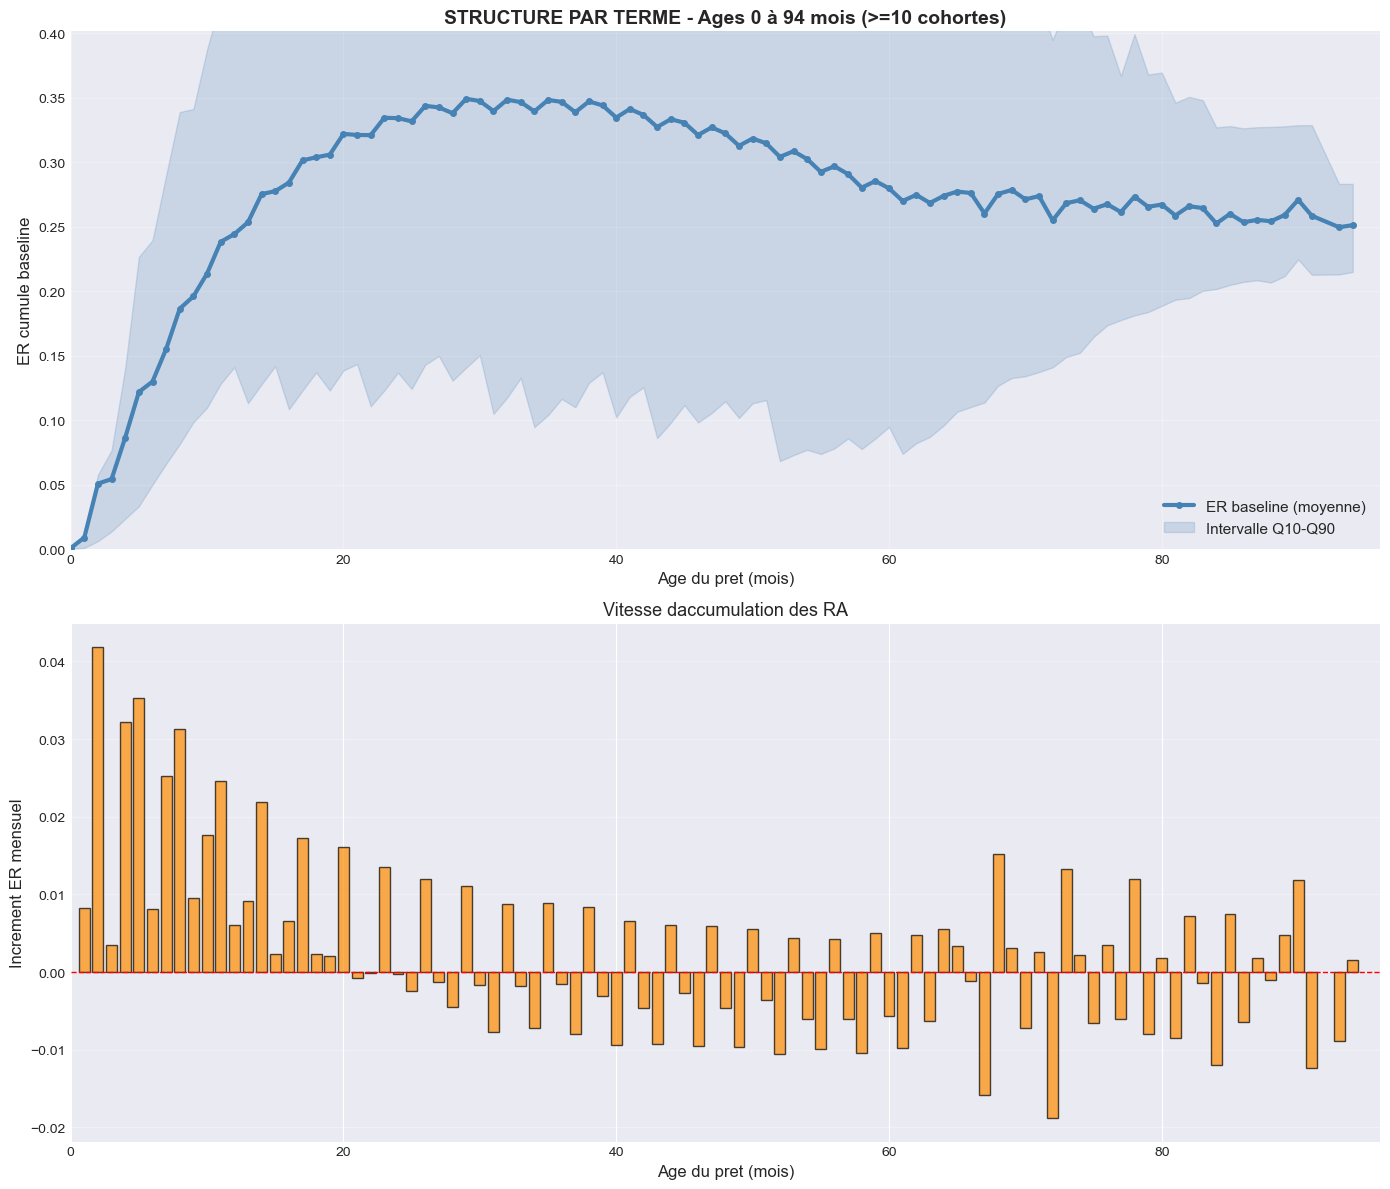


COURBE ER BASELINE (ages fiables)
  Age  ER baseline  Nb cohortes
------------------------------------------------------------
    0       0.0006           17
    1       0.0089           21
    2       0.0507           21
    3       0.0542           20
    4       0.0865           21
    5       0.1218           21
    6       0.1299           20
    7       0.1552           21
    8       0.1865           21
    9       0.1960           20
   10       0.2137           21
   11       0.2383           21
   12       0.2443           20
   13       0.2535           21
   14       0.2754           21
   15       0.2776           20
   16       0.2842           21
   17       0.3016           21
   18       0.3039           20
   19       0.3060           21
   20       0.3220           21
   21       0.3212           20
   22       0.3211           21
   23       0.3346           21
   24       0.3343           20
   25       0.3318           21
   26       0.3438           21
   27   

In [70]:
# =============================================================================
# COURBE ER BASELINE - AGES FIABLES UNIQUEMENT (>=10 cohortes)
# =============================================================================

# Compter combien de cohortes par âge
nb_cohortes_par_age = triangle_cumule.notna().sum(axis=0)

# FILTRER : ne garder QUE les âges avec au moins 10 cohortes
seuil_min_cohortes = 10
ages_fiables = nb_cohortes_par_age[nb_cohortes_par_age >= seuil_min_cohortes].index

print(f"\nAges disponibles : {len(nb_cohortes_par_age)} ages au total")
print(f"Ages fiables (>={seuil_min_cohortes} cohortes) : {len(ages_fiables)} ages retenus")
print(f"Plage : {int(min(ages_fiables))} à {int(max(ages_fiables))} mois")

# BASELINE SUR AGES FIABLES UNIQUEMENT
er_baseline_fiable = er_baseline[ages_fiables]
er_q10_fiable = er_q10[ages_fiables]
er_q90_fiable = er_q90[ages_fiables]

# Visualisation
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Extraire valeurs pour plot
ages_plot = sorted(er_baseline_fiable.index)
vals_baseline = [er_baseline_fiable[a] for a in ages_plot]
vals_q10 = [er_q10_fiable.get(a, 0) for a in ages_plot]
vals_q90 = [er_q90_fiable.get(a, er_baseline_fiable[a]) for a in ages_plot]

# Graphique 1 : Courbe baseline
axes[0].plot(ages_plot, vals_baseline, linewidth=3, color='steelblue', 
             label='ER baseline (moyenne)', marker='o', markersize=4)
axes[0].fill_between(ages_plot, vals_q10, vals_q90,
                      alpha=0.2, color='steelblue', label='Intervalle Q10-Q90')
axes[0].set_xlabel('Age du pret (mois)', fontsize=12)
axes[0].set_ylabel('ER cumule baseline', fontsize=12)
axes[0].set_title(f'STRUCTURE PAR TERME - Ages 0 à {int(max(ages_plot))} mois (>={seuil_min_cohortes} cohortes)', 
                  fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, max(ages_plot) + 2)
axes[0].set_ylim(0, max(vals_baseline) * 1.15)

# Graphique 2 : Increments
increments = er_baseline_fiable.diff().fillna(0)
ages_inc = sorted([a for a in increments.index if a > 0])
vals_inc = [increments[a] for a in ages_inc]

axes[1].bar(ages_inc, vals_inc, color='darkorange', edgecolor='black', alpha=0.7)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('Age du pret (mois)', fontsize=12)
axes[1].set_ylabel('Increment ER mensuel', fontsize=12)
axes[1].set_title('Vitesse daccumulation des RA', fontsize=13)
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].set_xlim(0, max(ages_plot) + 2)

plt.tight_layout()
plt.show()

# Afficher tableau
print("\nCOURBE ER BASELINE (ages fiables)")
print("=" * 60)
print(f"{'Age':>5} {'ER baseline':>12} {'Nb cohortes':>12}")
print("-" * 60)
for age in ages_plot:
    print(f"{age:>5.0f} {er_baseline_fiable[age]:>12.4f} {nb_cohortes_par_age[age]:>12.0f}")

# Sauvegarder
er_baseline_fiable.to_csv('cl_baseline_fiable.csv', header=['ER_baseline'])
print("\nFichier sauvegarde : cl_baseline_fiable.csv")